# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


In [1]:
!curl -L -o ./heart-disease-data.zip \
  https://www.kaggle.com/api/v1/datasets/download/redwankarimsony/heart-disease-data

!unzip -o ./heart-disease-data.zip
!cp -f ./heart_disease_uci.csv ./heartdiseaseuci_raw.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 12672  100 12672    0     0   5772      0  0:00:02  0:00:02 --:--:--     0
Archive:  ./heart-disease-data.zip
  inflating: heart_disease_uci.csv   


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
import warnings
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
def load_dataset(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Dataset tidak ditemukan: {csv_path}")

    return pd.read_csv(csv_path)

In [ ]:
def build_column_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary_rows = []

    for col in df.columns:
        series = df[col]
        non_null_series = series.dropna()

        if non_null_series.empty:
            lowest_value = np.nan
            highest_value = np.nan
        elif pd.api.types.is_numeric_dtype(series):
            lowest_value = series.min(skipna=True)
            highest_value = series.max(skipna=True)
        else:
            string_series = non_null_series.astype(str)
            lowest_value = string_series.min()
            highest_value = string_series.max()

        summary_rows.append(
            {
                "column": col,
                "dtype": series.dtype,
                "missing_count": series.isna().sum(),
                "lowest_value": lowest_value,
                "highest_value": highest_value,
                "total_unique_value": series.nunique(dropna=True),
            }
        )

    return pd.DataFrame(summary_rows)

In [29]:
def check_dataset(df: pd.DataFrame) -> None:
    n_rows, n_cols = df.shape
    print(f"Dataset shape: {n_rows} Rows x {n_cols} Columns", end="\n\n")

    print("Describe dataset:")
    print(df.describe(include="all"), end="\n\n")

    missing_counts = df.isnull().sum()
    columns_with_missing = missing_counts[missing_counts > 0].sort_values(
        ascending=False
    )
    columns_without_missing = missing_counts[missing_counts == 0]

    print("Kolom yang punya missing values:")
    if columns_with_missing.empty:
        print("Tidak ada kolom yang punya missing values.")
    else:
        missing_table = columns_with_missing.rename("missing_count").to_frame()
        missing_table["missing_pct"] = (
            missing_table["missing_count"] / len(df) * 100
        ).round(2)
        print(missing_table)
    print()

    print("Kolom yang tidak punya missing values:")
    if columns_without_missing.empty:
        print("Tidak ada kolom yang bebas missing values.")
    else:
        print(columns_without_missing.index.tolist())
    print()

    duplicate_rows = df[df.duplicated(keep=False)]
    print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
    print("Baris yang duplikat:")
    if duplicate_rows.empty:
        print("Tidak ada baris duplikat.")
    else:
        print(duplicate_rows)
    print()

    print("Lowest value, highest value, dan total unique value semua kolom:")
    print(build_column_summary(df), end="\n\n")

In [25]:
parent_dir = os.path.dirname(os.path.abspath("."))
df = load_dataset(os.path.join(parent_dir, "heartdisease_raw.csv"))
check_dataset(df)

Dataset shape: 920 Rows x 16 Columns

Describe dataset:
                id         age   sex    dataset            cp    trestbps  \
count   920.000000  920.000000   920        920           920  861.000000   
unique         NaN         NaN     2          4             4         NaN   
top            NaN         NaN  Male  Cleveland  asymptomatic         NaN   
freq           NaN         NaN   726        304           496         NaN   
mean    460.500000   53.510870   NaN        NaN           NaN  132.132404   
std     265.725422    9.424685   NaN        NaN           NaN   19.066070   
min       1.000000   28.000000   NaN        NaN           NaN    0.000000   
25%     230.750000   47.000000   NaN        NaN           NaN  120.000000   
50%     460.500000   54.000000   NaN        NaN           NaN  130.000000   
75%     690.250000   60.000000   NaN        NaN           NaN  140.000000   
max     920.000000   77.000000   NaN        NaN           NaN  200.000000   

              chol 

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [26]:
def save_and_show_plot(filename: str, output_dir: str) -> None:
    os.makedirs(output_dir, exist_ok=True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename), dpi=150, bbox_inches="tight")
    if "agg" not in plt.get_backend().lower():
        plt.show()
    plt.close()

In [31]:
RANDOM_STATE = 42
TARGET_COLUMN = "num"
CURRENT_DIR = os.path.abspath(".")
OUTPUT_DIR = os.getenv(
    "OUTPUT_DIR", os.path.join(CURRENT_DIR, "heartdisease_preprocessing")
)

# Exploratory Data Analysis
Dataset shape: 920 Rows x 16 Columns

Describe dataset:
                id         age   sex    dataset            cp    trestbps  \
count   920.000000  920.000000   920        920           920  861.000000   
unique         NaN         NaN     2          4             4         NaN   
top            NaN         NaN  Male  Cleveland  asymptomatic         NaN   
freq           NaN         NaN   726        304           496         NaN   
mean    460.500000   53.510870   NaN        NaN           NaN  132.132404   
std     265.725422    9.424685   NaN        NaN           NaN   19.066070   
min       1.000000   28.000000   NaN        NaN           NaN    0.000000   
25%     230.750000   47.000000   NaN        NaN           NaN  120.000000   
50%     460.500000   54.000000   NaN        NaN           NaN  130.000000   
75%     690.250000   60.000000   NaN        NaN           NaN  140.000000   
max     920.000000   77.000000   NaN        NaN           NaN  200.00

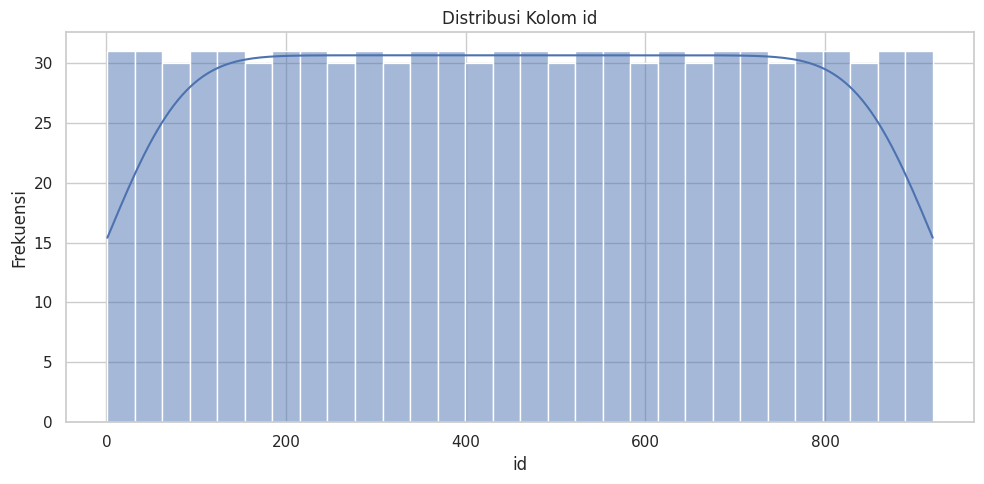

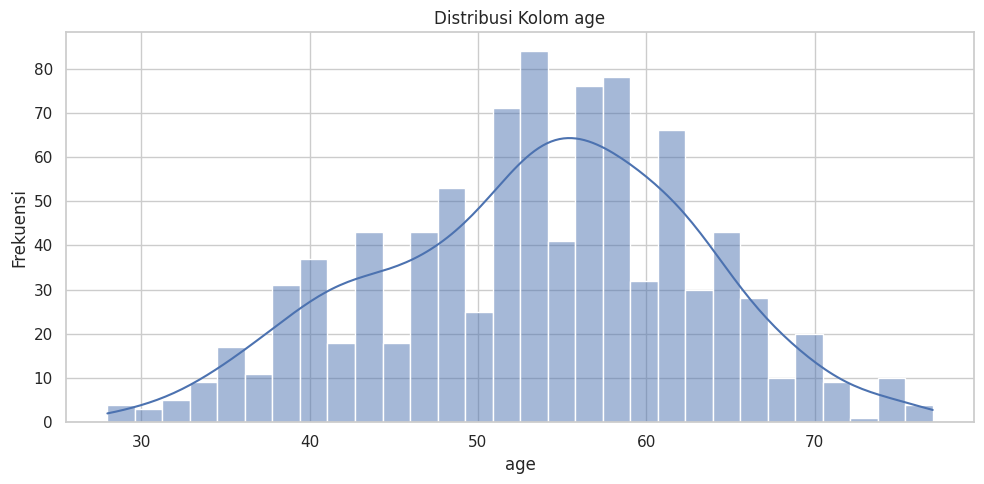

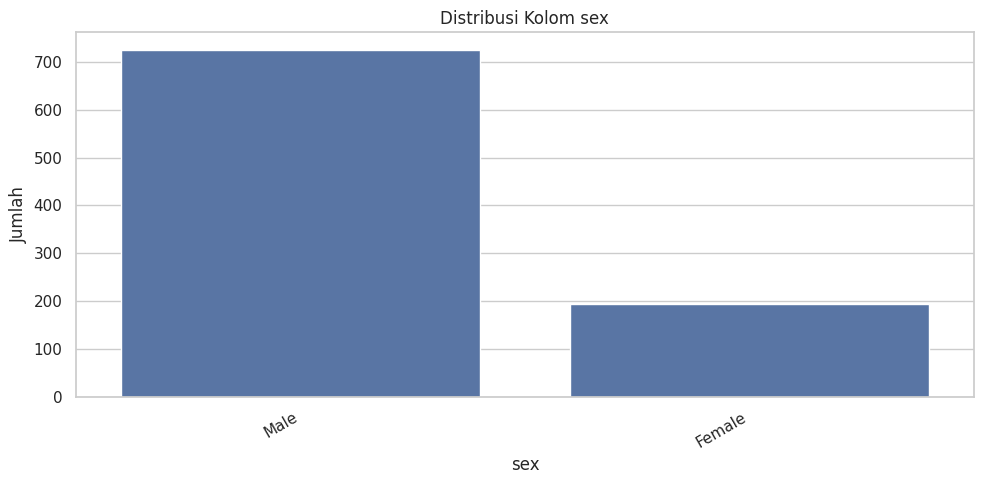

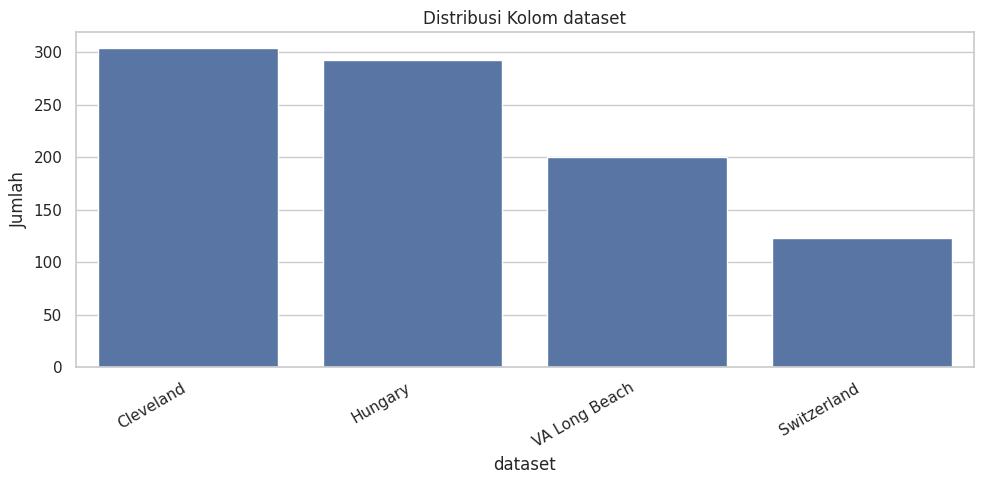

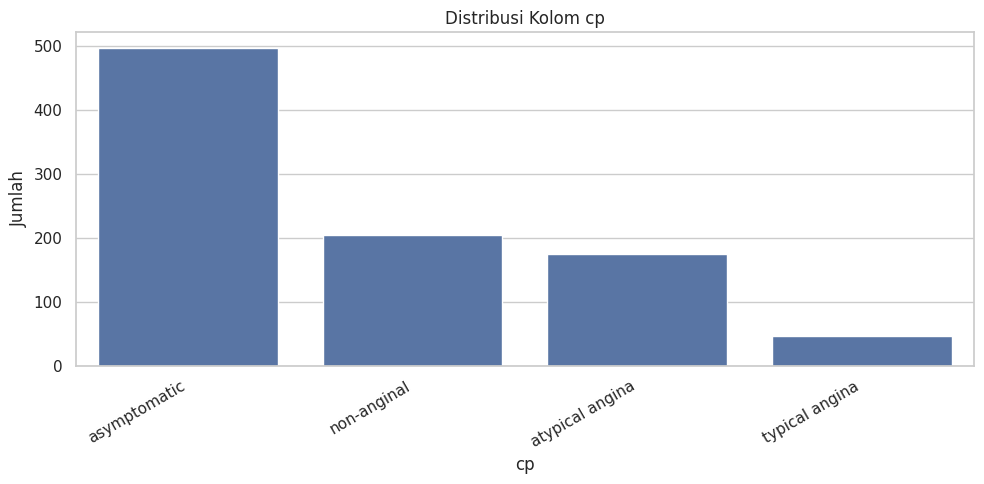

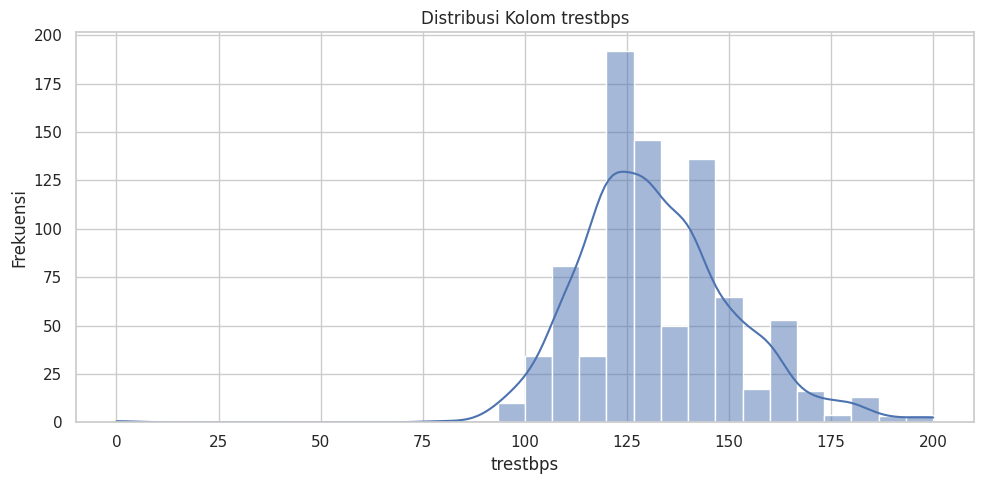

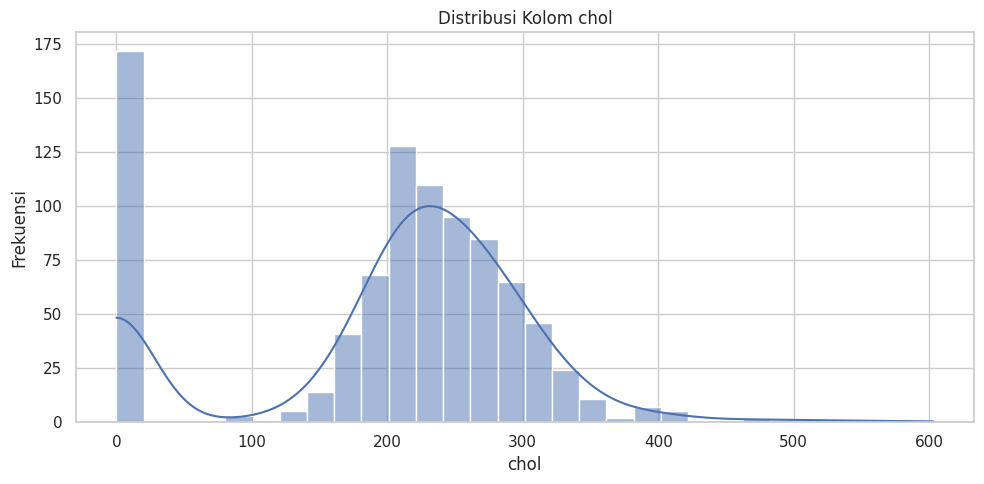

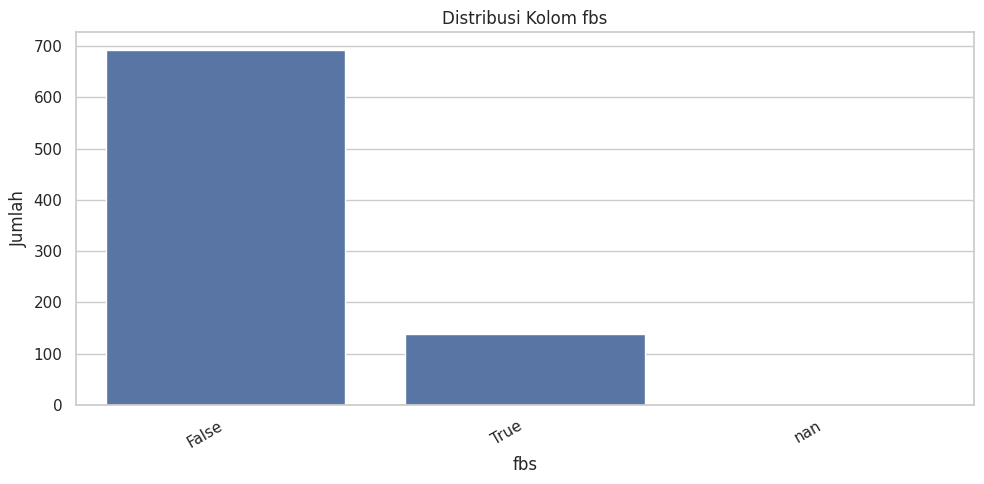

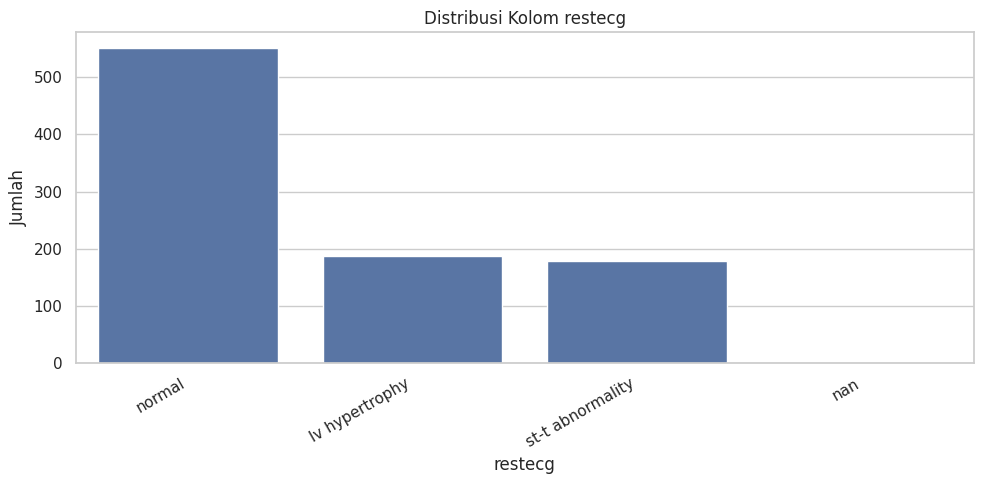

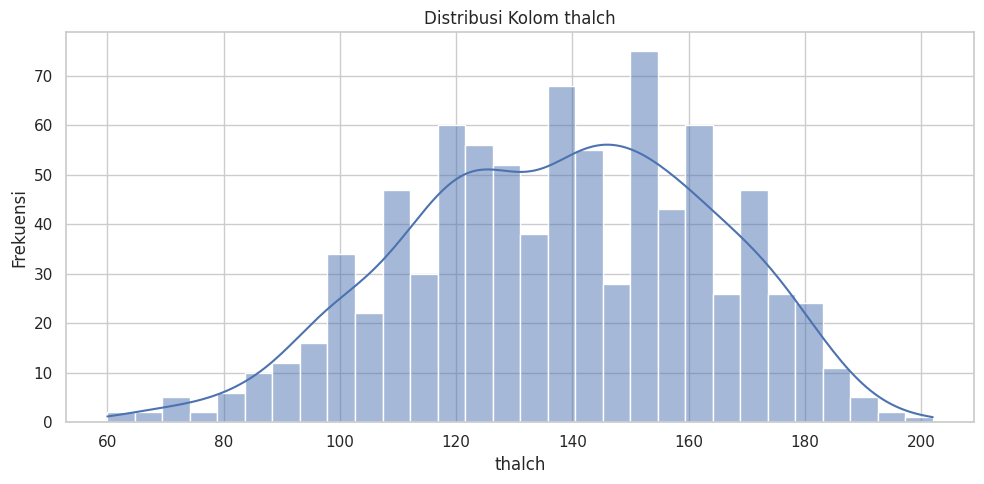

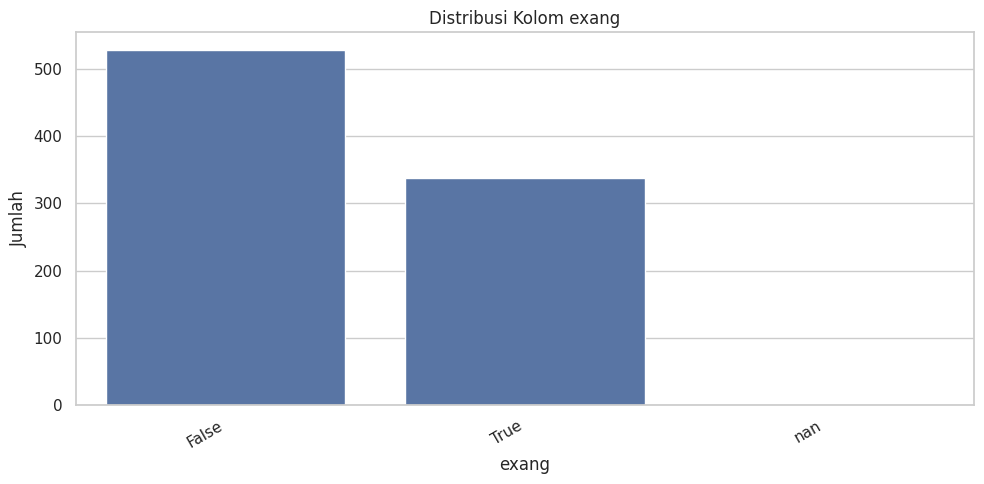

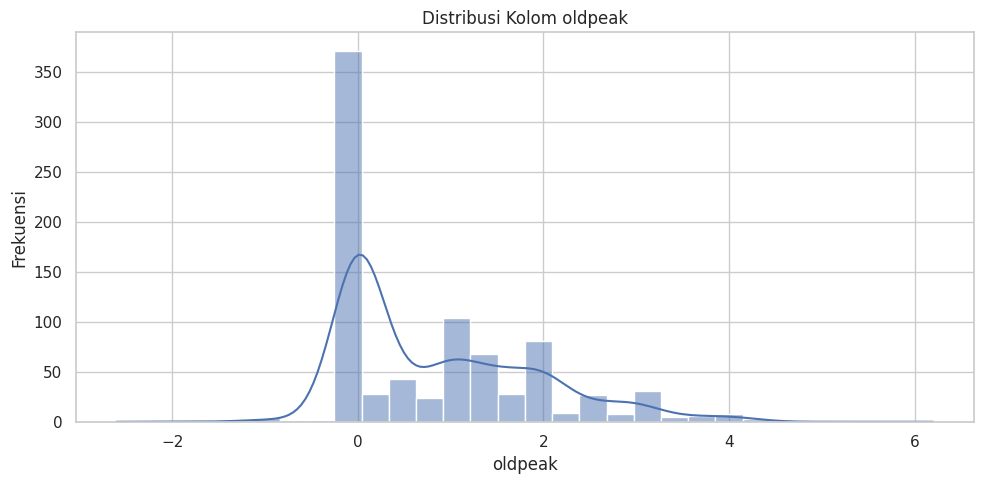

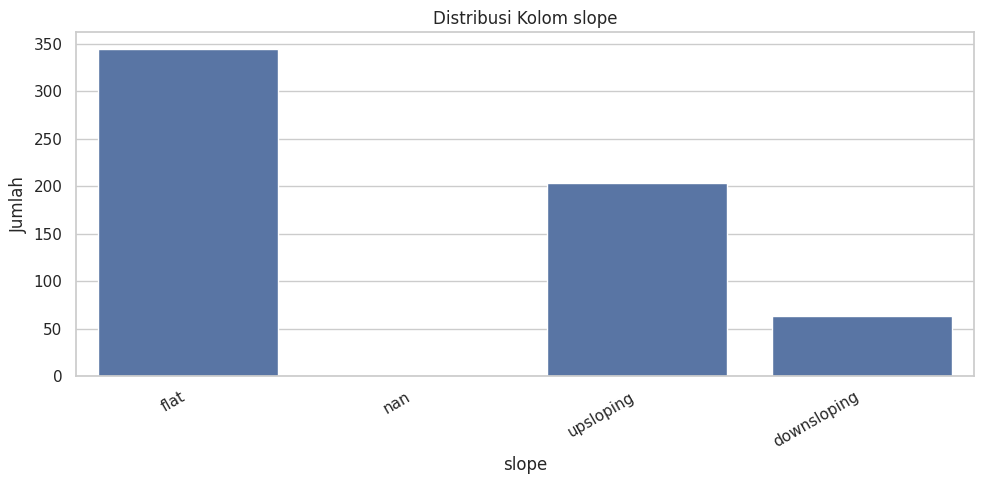

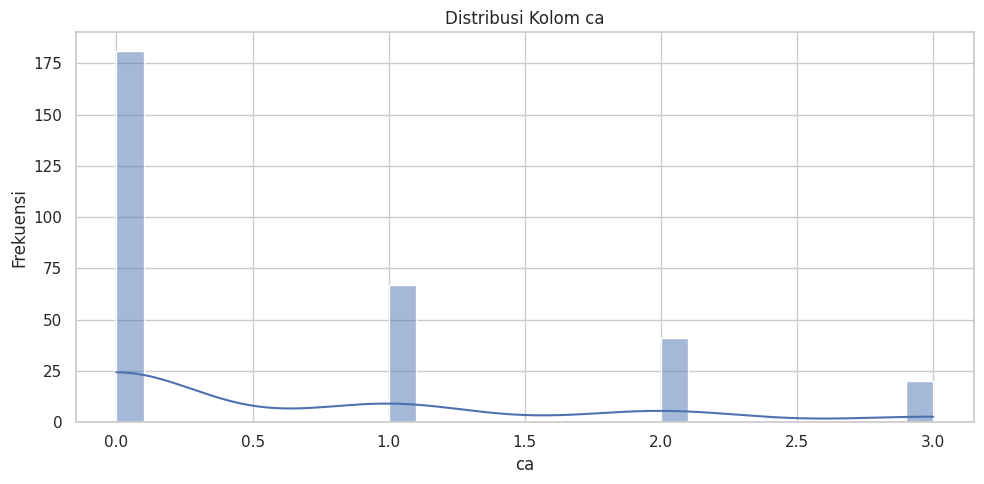

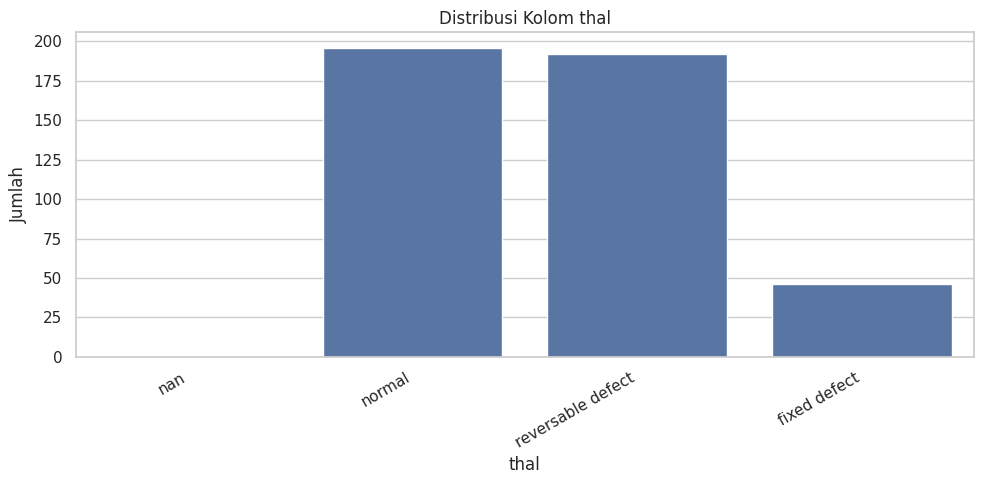

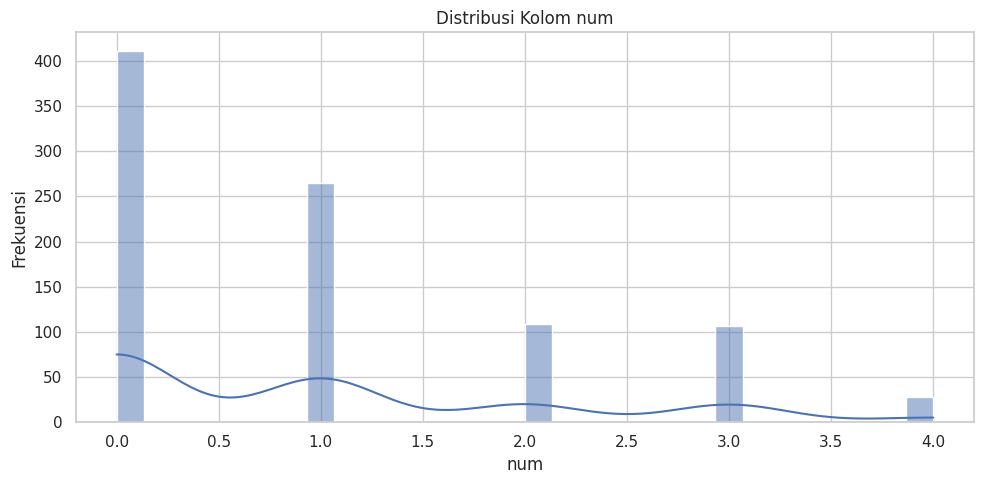

In [32]:
sns.set_theme(style="whitegrid")

print("# Exploratory Data Analysis")
n_rows, n_cols = df.shape
print(f"Dataset shape: {n_rows} Rows x {n_cols} Columns", end="\n\n")

print("Describe dataset:")
print(df.describe(include="all"), end="\n\n")

missing_counts = df.isnull().sum()
columns_with_missing = missing_counts[missing_counts > 0].sort_values(ascending=False)
columns_without_missing = missing_counts[missing_counts == 0]

print("Kolom yang punya missing values:")
if columns_with_missing.empty:
    print("Tidak ada kolom yang punya missing values.")
else:
    missing_table = columns_with_missing.rename("missing_count").to_frame()
    missing_table["missing_pct"] = (
        missing_table["missing_count"] / len(df) * 100
    ).round(2)
    print(missing_table)
print()

print("Kolom yang tidak punya missing values:")
if columns_without_missing.empty:
    print("Tidak ada kolom yang bebas missing values.")
else:
    print(columns_without_missing.index.tolist())
print()

duplicate_rows = df[df.duplicated(keep=False)]
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print("Baris yang duplikat:")
if duplicate_rows.empty:
    print("Tidak ada baris duplikat.")
else:
    print(duplicate_rows)
print()

summary_rows = []
for col in df.columns:
    series = df[col]
    non_null_series = series.dropna()

    if non_null_series.empty:
        lowest_value = np.nan
        highest_value = np.nan
    elif pd.api.types.is_numeric_dtype(series):
        lowest_value = series.min(skipna=True)
        highest_value = series.max(skipna=True)
    else:
        string_series = non_null_series.astype(str)
        lowest_value = string_series.min()
        highest_value = string_series.max()

    summary_rows.append(
        {
            "column": col,
            "dtype": series.dtype,
            "missing_count": series.isna().sum(),
            "lowest_value": lowest_value,
            "highest_value": highest_value,
            "total_unique_value": series.nunique(dropna=True),
        }
    )

column_summary = pd.DataFrame(summary_rows)
print("Lowest value, highest value, dan total unique value semua kolom:")
print(column_summary, end="\n\n")

health_status = np.where(df[TARGET_COLUMN] > 0, "Sakit", "Sehat")
health_counts = pd.Series(health_status, name="health_status").value_counts()
health_summary = pd.DataFrame(
    {
        "count": health_counts,
        "percentage": (health_counts / len(df) * 100).round(2),
    }
)

stage_counts = df[TARGET_COLUMN].value_counts().sort_index()
stage_summary = pd.DataFrame(
    {
        "count": stage_counts,
        "percentage": (stage_counts / len(df) * 100).round(2),
    }
)

print("Kolom num - jumlah dan persentase orang sakit dan sehat:")
print(health_summary, end="\n\n")

print("Kolom num - jumlah dan persentase berdasarkan stage:")
print(stage_summary, end="\n\n")

for col in df.columns:
    plt.figure(figsize=(10, 5))

    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(data=df, x=col, bins=30, kde=True)
        plt.title(f"Distribusi Kolom {col}")
        plt.xlabel(col)
        plt.ylabel("Frekuensi")
        save_and_show_plot(f"distribution_{col}.png", OUTPUT_DIR)
    else:
        order = df[col].value_counts(dropna=False).index
        sns.countplot(data=df, x=col, order=order)
        plt.title(f"Distribusi Kolom {col}")
        plt.xlabel(col)
        plt.ylabel("Jumlah")
        plt.xticks(rotation=30, ha="right")
        save_and_show_plot(f"distribution_{col}.png", OUTPUT_DIR)

### Analisis:
distribusi semua kolom menunjukkan dataset didominasi pasien Male
sebanyak 726 baris, chest pain asymptomatic sebanyak 496 baris, dan stage num
0/1. Kolom trestbps dan chol memiliki nilai minimum 0 sehingga perlu ditinjau
sebagai nilai yang tidak wajar untuk tekanan darah dan kolesterol.

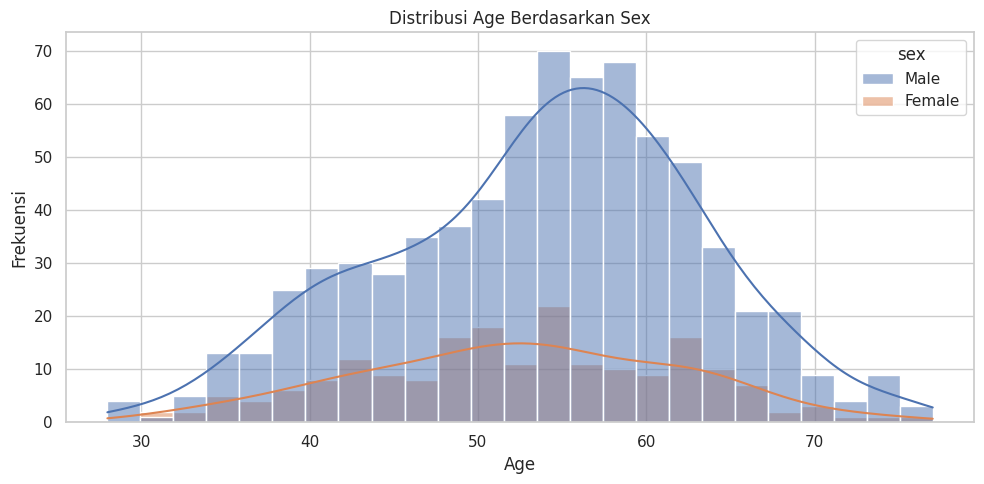

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="age", hue="sex", bins=25, kde=True, multiple="layer")
plt.title("Distribusi Age Berdasarkan Sex")
plt.xlabel("Age")
plt.ylabel("Frekuensi")
save_and_show_plot("relationship_sex_age.png", OUTPUT_DIR)

### Analisis:
distribusi umur Male dan Female relatif mirip. Median umur Male
adalah 55 tahun, sedikit lebih tinggi daripada Female yaitu 53 tahun, dan
jumlah Male jauh lebih banyak daripada Female.


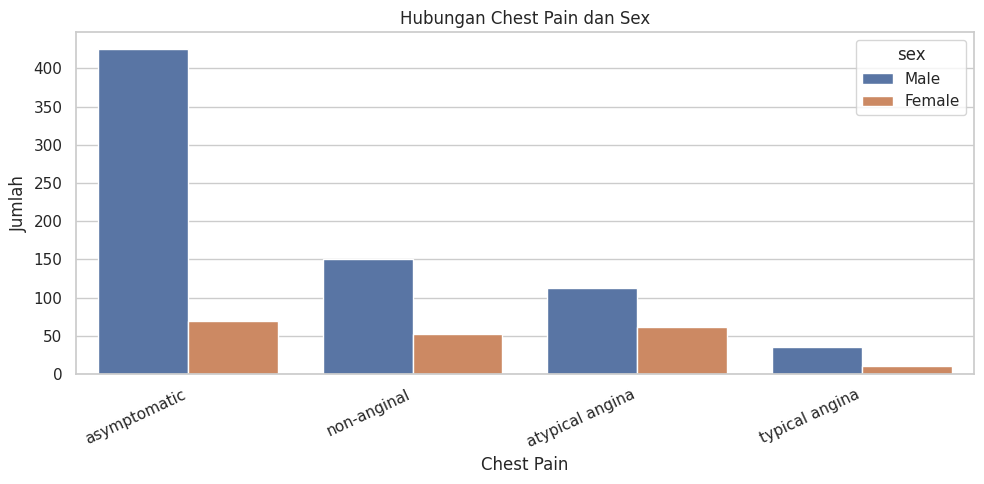

In [34]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="cp", hue="sex", order=df["cp"].value_counts().index)
plt.title("Hubungan Chest Pain dan Sex")
plt.xlabel("Chest Pain")
plt.ylabel("Jumlah")
plt.xticks(rotation=25, ha="right")
save_and_show_plot("relationship_chest_pain_sex.png", OUTPUT_DIR)

### Analisis:
kategori chest pain asymptomatic paling dominan, terutama pada Male
sebanyak 426 baris. Pada Female, atypical angina muncul 61 baris dan jauh lebih
banyak daripada typical angina yang hanya 10 baris.

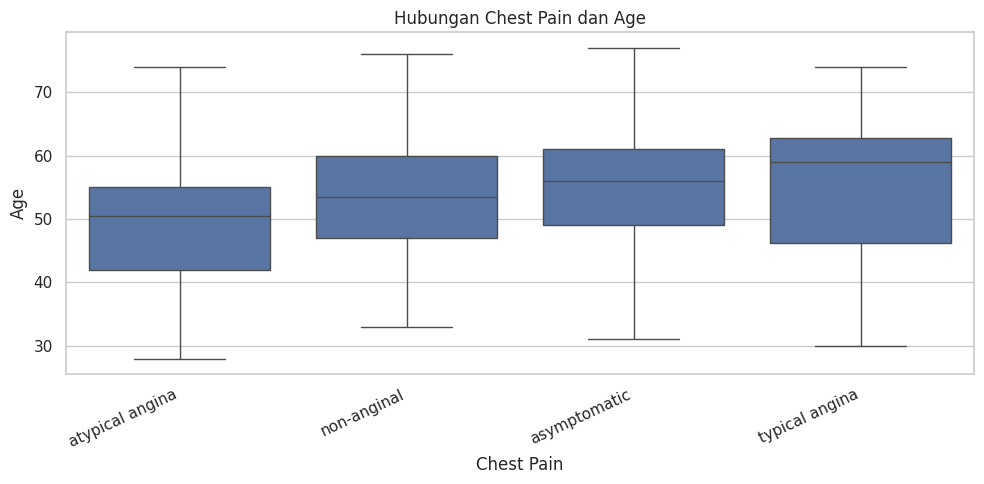

In [35]:
plt.figure(figsize=(10, 5))
chest_pain_order = df.groupby("cp")["age"].median().sort_values().index
sns.boxplot(data=df, x="cp", y="age", order=chest_pain_order)
plt.title("Hubungan Chest Pain dan Age")
plt.xlabel("Chest Pain")
plt.ylabel("Age")
plt.xticks(rotation=25, ha="right")
save_and_show_plot("relationship_chest_pain_age.png", OUTPUT_DIR)

### Analisis:
asymptomatic dan typical angina cenderung muncul pada umur yang lebih
tinggi dengan rata-rata sekitar 55 tahun, sedangkan atypical angina memiliki
rata-rata umur lebih muda yaitu sekitar 49 tahun.

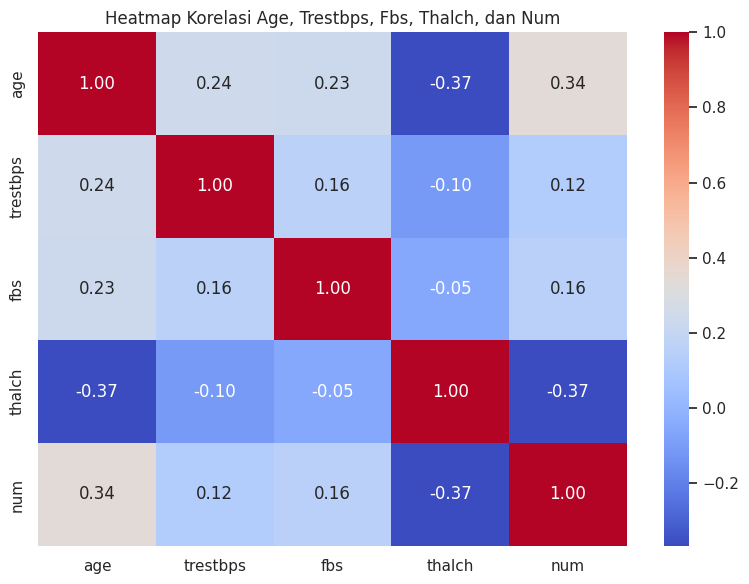

In [36]:
heatmap_df = df[["age", "trestbps", "fbs", "thalch", "num"]].copy()
heatmap_df["fbs"] = heatmap_df["fbs"].map({True: 1, False: 0})
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Age, Trestbps, Fbs, Thalch, dan Num")
save_and_show_plot("heatmap_age_trestbps_fbs_thalch_num.png", OUTPUT_DIR)

### Analisis:
age berkorelasi positif dengan num sekitar 0.34, thalch berkorelasi
negatif dengan num sekitar -0.37, dan age juga berkorelasi negatif dengan
thalch sekitar -0.37.

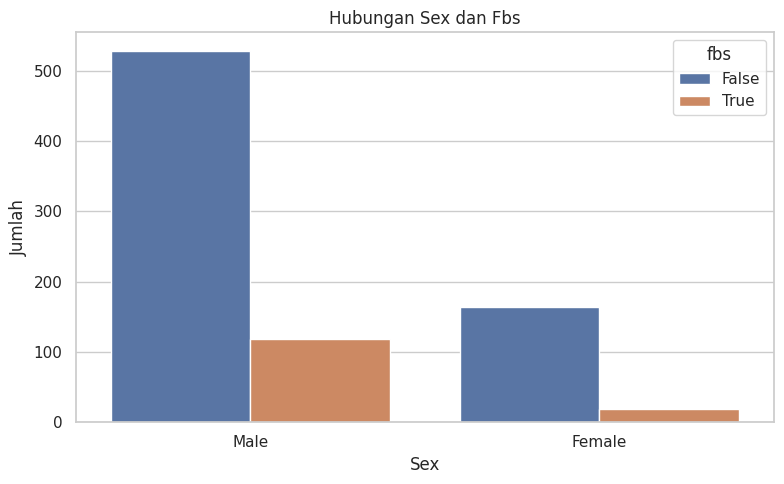

In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="sex", hue="fbs")
plt.title("Hubungan Sex dan Fbs")
plt.xlabel("Sex")
plt.ylabel("Jumlah")
save_and_show_plot("relationship_sex_fbs.png", OUTPUT_DIR)

### Analisis:
`fbs=True` lebih banyak ditemukan pada Male sebanyak 119 baris
dibanding Female sebanyak 19 baris.

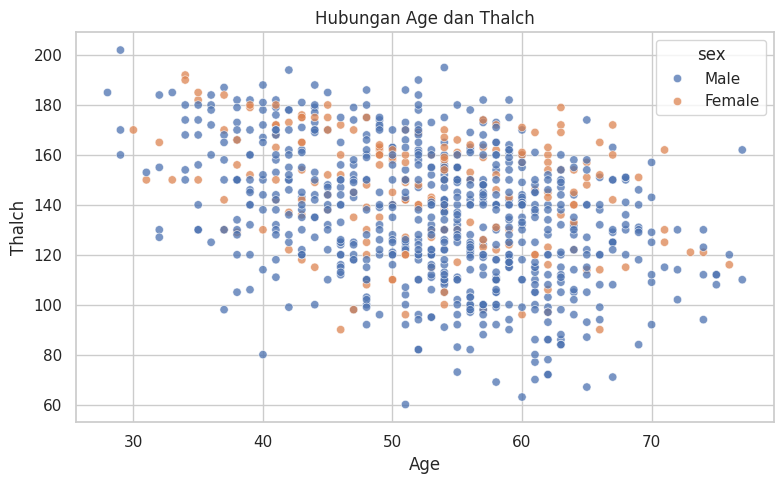

In [38]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="thalch", hue="sex", alpha=0.75)
plt.title("Hubungan Age dan Thalch")
plt.xlabel("Age")
plt.ylabel("Thalch")
save_and_show_plot("relationship_age_thalch.png", OUTPUT_DIR)

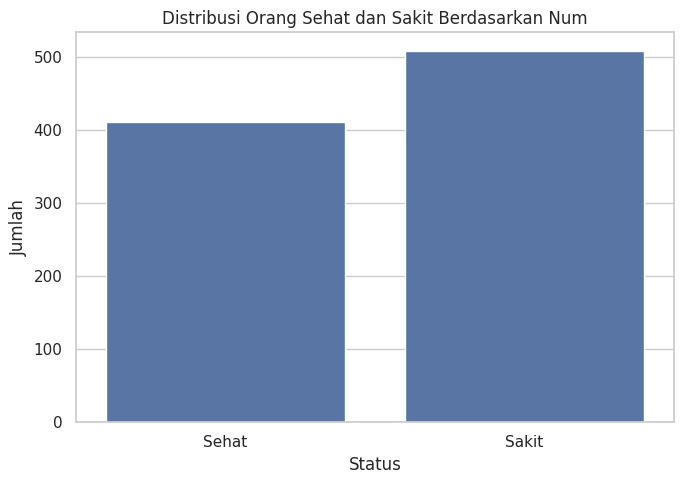

In [39]:
health_df = df.assign(health_status=np.where(df[TARGET_COLUMN] > 0, "Sakit", "Sehat"))
plt.figure(figsize=(7, 5))
sns.countplot(data=health_df, x="health_status", order=["Sehat", "Sakit"])
plt.title("Distribusi Orang Sehat dan Sakit Berdasarkan Num")
plt.xlabel("Status")
plt.ylabel("Jumlah")
save_and_show_plot("num_healthy_sick_distribution.png", OUTPUT_DIR)

### Analisis:
kelompok Sakit lebih banyak daripada Sehat, yaitu 509 orang atau 55.33% dibanding 411 orang atau 44.67%.

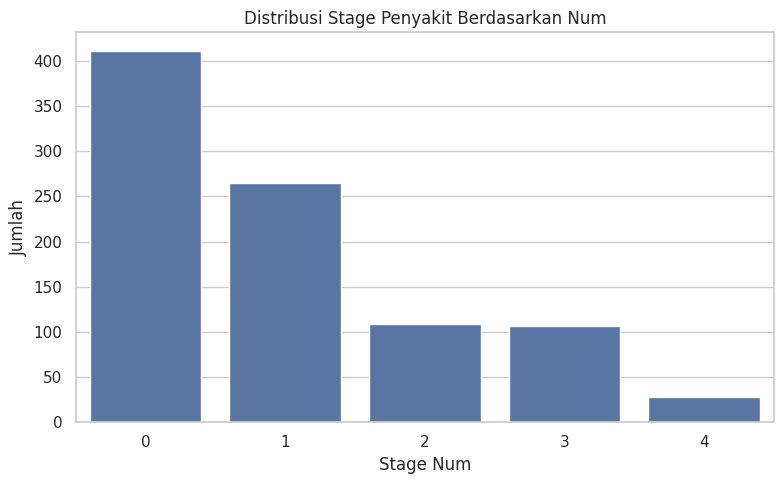

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, x=TARGET_COLUMN, order=sorted(df[TARGET_COLUMN].dropna().unique())
)
plt.title("Distribusi Stage Penyakit Berdasarkan Num")
plt.xlabel("Stage Num")
plt.ylabel("Jumlah")
save_and_show_plot("num_stage_distribution.png", OUTPUT_DIR)

### Analisis:
stage num 0 adalah kategori terbanyak, diikuti stage 1. Stage 4 adalah kategori paling sedikit sehingga distribusi stage tidak seimbang.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [30]:
check_dataset(df)

Dataset shape: 920 Rows x 16 Columns

Describe dataset:
                id         age   sex    dataset            cp    trestbps  \
count   920.000000  920.000000   920        920           920  861.000000   
unique         NaN         NaN     2          4             4         NaN   
top            NaN         NaN  Male  Cleveland  asymptomatic         NaN   
freq           NaN         NaN   726        304           496         NaN   
mean    460.500000   53.510870   NaN        NaN           NaN  132.132404   
std     265.725422    9.424685   NaN        NaN           NaN   19.066070   
min       1.000000   28.000000   NaN        NaN           NaN    0.000000   
25%     230.750000   47.000000   NaN        NaN           NaN  120.000000   
50%     460.500000   54.000000   NaN        NaN           NaN  130.000000   
75%     690.250000   60.000000   NaN        NaN           NaN  140.000000   
max     920.000000   77.000000   NaN        NaN           NaN  200.000000   

              chol 

In [17]:
def clean_raw_data(
    df: pd.DataFrame,
    target_column: str,
    drop_columns: list[str],
    numeric_features: list[str],
    bool_features: list[str],
) -> pd.DataFrame:
    df = df.copy()

    df = df.drop(columns=drop_columns, errors="ignore")

    for col in bool_features:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.lower()
                .replace(
                    {
                        "true": True,
                        "false": False,
                        "1": True,
                        "0": False,
                        "yes": True,
                        "no": False,
                        "nan": np.nan,
                        "none": np.nan,
                    }
                )
            )

    for col in numeric_features:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df[target_column] = pd.to_numeric(df[target_column], errors="coerce")

    df = df.drop_duplicates()
    df = df.dropna(subset=[target_column])

    df[target_column] = (df[target_column] > 0).astype(int)

    return df

In [18]:
def build_preprocessor(
    numeric_features: list[str],
    string_categorical_features: list[str],
    bool_features: list[str],
    random_state: int,
) -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                IterativeImputer(
                    estimator=RandomForestRegressor(
                        n_estimators=100,
                        max_depth=None,
                        min_samples_leaf=5,
                        max_features=1.0,
                        bootstrap=True,
                        max_samples=0.5,
                        random_state=random_state,
                        n_jobs=-1,
                    ),
                    max_iter=20,
                    tol=0.001,
                    initial_strategy="median",
                    imputation_order="ascending",
                    random_state=random_state,
                ),
            ),
            ("scaler", StandardScaler()),
        ]
    )

    string_categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )

    bool_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                    drop="if_binary",
                ),
            ),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", string_categorical_pipeline, string_categorical_features),
            ("bool", bool_pipeline, bool_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return preprocessor

In [19]:
def preprocess_data(
    df: pd.DataFrame,
    target_column: str,
    drop_columns: list[str],
    numeric_features: list[str],
    string_categorical_features: list[str],
    bool_features: list[str],
    test_size: float,
    random_state: int,
    output_dir: str,
) -> None:
    data = clean_raw_data(
        df, target_column, drop_columns, numeric_features, bool_features
    )

    X = data.drop(columns=[target_column])
    y = data[target_column].astype(int)

    print("# Dataset setelah preprocessing awal")
    check_dataset(data)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    preprocessor = build_preprocessor(
        numeric_features,
        string_categorical_features,
        bool_features,
        random_state,
    )
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)
    feature_names = preprocessor.get_feature_names_out()

    X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)
    y_train_df = pd.DataFrame({target_column: y_train.reset_index(drop=True)})
    y_test_df = pd.DataFrame({target_column: y_test.reset_index(drop=True)})

    print("# Dataset X_train setelah preprocessing pipeline")
    check_dataset(X_train_df)

    os.makedirs(output_dir, exist_ok=True)
    X_train_df.to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
    X_test_df.to_csv(os.path.join(output_dir, "X_test.csv"), index=False)
    y_train_df.to_csv(os.path.join(output_dir, "y_train.csv"), index=False)
    y_test_df.to_csv(os.path.join(output_dir, "y_test.csv"), index=False)

    joblib.dump(preprocessor, os.path.join(output_dir, "preprocessor.joblib"))


In [22]:
RANDOM_STATE = 42
TARGET_COLUMN = "num"
DROP_COLUMNS = ["id", "dataset"]

STRING_CATEGORICAL_FEATURES = ["sex", "cp", "restecg", "slope", "thal"]
NUMERIC_FEATURES = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
BOOL_FEATURES = ["fbs", "exang"]
TEST_SIZE = 0.2
CURRENT_DIR = os.path.abspath(".")
OUTPUT_DIR = os.getenv(
    "OUTPUT_DIR", os.path.join(CURRENT_DIR, "heartdisease_preprocessing")
)

In [24]:
preprocess_data(
    df,
    TARGET_COLUMN,
    DROP_COLUMNS,
    NUMERIC_FEATURES,
    STRING_CATEGORICAL_FEATURES,
    BOOL_FEATURES,
    TEST_SIZE,
    RANDOM_STATE,
    OUTPUT_DIR,
)

# Dataset setelah preprocessing awal
Dataset shape: 918 Rows x 14 Columns

Describe dataset:
               age   sex            cp    trestbps        chol    fbs restecg  \
count   918.000000   918           918  859.000000  889.000000    828     916   
unique         NaN     2             4         NaN         NaN      2       3   
top            NaN  Male  asymptomatic         NaN         NaN  False  normal   
freq           NaN   725           496         NaN         NaN    690     550   
mean     53.510893   NaN           NaN  132.137369  199.107987    NaN     NaN   
std       9.432617   NaN           NaN   19.063560  110.841162    NaN     NaN   
min      28.000000   NaN           NaN    0.000000    0.000000    NaN     NaN   
25%      47.000000   NaN           NaN  120.000000  175.000000    NaN     NaN   
50%      54.000000   NaN           NaN  130.000000  223.000000    NaN     NaN   
75%      60.000000   NaN           NaN  140.000000  268.000000    NaN     NaN   
max      77.0000